<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/dnanf_geometry_aware_tube_core_sweep_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometry-aware DNANF tube-count and air-core-diameter sweep

이 Colab은 HCF의 **outer tube 수** 또는 **air-core 직경**을 변경할 때
서로 연결된 형상·광학·시스템 파라미터를 함께 갱신합니다.

$$
(N,D_{core},t,g)\rightarrow d_{tube}\rightarrow(f_1,f_2)
\rightarrow n_{eff}(\lambda)\rightarrow D(\lambda),A_{eff}(\lambda)
\rightarrow\gamma(\lambda),\alpha(\lambda)\rightarrow\eta,P_{ASE}
\rightarrow SNR,T_{tot}.
$$

기본 tube 비교는 사용자가 요청한 `2, 4, 6, 8, 10`과 논문 기준인 `5`를 포함합니다.
단, Hasan 경험식의 검증 범위는 주로 `N=6~12`이므로 `N=2`는 폐쇄 ring을 만들 수 없어
자동 제외하고, `N=4`는 외삽값으로 표시합니다.

## 중요한 모델 경계

- `f1/f2`, 분산, capillary-mode 유효면적은 빠른 해석 모델로 자동 갱신됩니다.
- core 직경 변화에 따른 leakage-loss 경향은 bouncing-ray 기반 proxy로 반영됩니다.
- **tube 수에 따른 실제 confinement loss, HOM loss, bend loss, IMI는 full-vector FEM 또는 측정값이 필요합니다.**
  코드의 `FEM_OVERRIDES`에 COMSOL/Lumerical/측정 결과를 입력하면 ASE·SNR·처리량까지 자동 반영됩니다.
- 따라서 기본 결과는 geometry-aware sensitivity study이며, tube 설계의 최종 우열 판정이 아닙니다.


In [1]:
%pip -q install numpy scipy pandas matplotlib


In [2]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

try:
    from IPython.display import display
except ImportError:
    display = print

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER_POWER = 10.0 / np.log(10.0)
BESSEL_AEFF_FACTOR = 1.4971689509  # Aeff/R_eff^2 for scalar J0(u01 r/R_eff)

REQUESTED_TUBE_COUNTS = (2, 4, 6, 8, 10)
REFERENCE_TUBE_COUNT = 5
ALL_TUBE_COUNTS = (2, 4, 5, 6, 8, 10)
CORE_DIAMETERS_UM = (20.0, 29.5, 40.0, 50.0)
REFERENCE_CORE_DIAMETER_UM = 29.5


## 1. 독립적으로 바꾸는 값과 자동으로 바뀌는 값

독립 입력은 `tube_count`, `core_diameter_um`, `membrane_thickness_um`,
`gap policy`, `nesting_order`입니다. 기본값에서는 기준 5-tube 구조의
$R/g$ 비를 보존하고 tube 외경을 다음 식으로 다시 계산합니다.

$$
d_{tube}=\frac{D_{core}\sin(\pi/N)-g}{1-\sin(\pi/N)}.
$$

C-band를 유지하기 위해 membrane thickness는 기본적으로 0.50 µm로 고정합니다.
wall thickness까지 비례 확대하면 anti-resonance window 자체가 이동하기 때문입니다.


In [3]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_diameter_um: float
    tube_count: int
    membrane_thickness_um: float = 0.50
    nesting_order: int = 2
    gap_um: float | None = None
    outer_tube_diameter_um: float | None = None

    @property
    def core_radius_um(self) -> float:
        return 0.5 * self.core_diameter_um

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def gap_m(self) -> float:
        return float(self.gap_um) * 1e-6

    @property
    def outer_tube_diameter_m(self) -> float:
        return float(self.outer_tube_diameter_um) * 1e-6

    @property
    def microstructure_diameter_um(self) -> float:
        return self.core_diameter_um + 2.0 * float(self.outer_tube_diameter_um)


@dataclass(frozen=True)
class HCFLink:
    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0
    reference_gamma_per_w_km: float = 5e-4
    reference_imi_db_per_km: float = -52.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


LINK = HCFLink()

# Original 5-tube anchor: R=14.75 um, d=31.05 um, t=0.50 um.
_theta_ref = np.pi / 5.0
REFERENCE_GAP_UM = (
    REFERENCE_CORE_DIAMETER_UM * np.sin(_theta_ref)
    - 31.05 * (1.0 - np.sin(_theta_ref))
)
REFERENCE_R_OVER_G = (0.5 * REFERENCE_CORE_DIAMETER_UM) / REFERENCE_GAP_UM


def make_geometry(
    tube_count: int,
    core_diameter_um: float,
    membrane_thickness_um: float = 0.50,
    nesting_order: int = 2,
    preserve_r_over_g: bool = True,
    explicit_gap_um: float | None = None,
) -> DNANFGeometry:
    if tube_count < 3:
        return DNANFGeometry(
            core_diameter_um=core_diameter_um,
            tube_count=tube_count,
            membrane_thickness_um=membrane_thickness_um,
            nesting_order=nesting_order,
            gap_um=np.nan,
            outer_tube_diameter_um=np.nan,
        )

    radius_um = 0.5 * core_diameter_um
    if explicit_gap_um is not None:
        gap_um = float(explicit_gap_um)
    elif preserve_r_over_g:
        gap_um = radius_um / REFERENCE_R_OVER_G
    else:
        gap_um = REFERENCE_GAP_UM

    s = np.sin(np.pi / tube_count)
    tube_diameter_um = (core_diameter_um * s - gap_um) / (1.0 - s)
    return DNANFGeometry(
        core_diameter_um=float(core_diameter_um),
        tube_count=int(tube_count),
        membrane_thickness_um=float(membrane_thickness_um),
        nesting_order=int(nesting_order),
        gap_um=float(gap_um),
        outer_tube_diameter_um=float(tube_diameter_um),
    )


REFERENCE_GEOMETRY = make_geometry(5, REFERENCE_CORE_DIAMETER_UM)


def geometry_validity(geometry: DNANFGeometry) -> tuple[bool, str]:
    if geometry.tube_count < 3:
        return False, "invalid: N<3 cannot form a closed tube ring"
    if not np.isfinite(geometry.outer_tube_diameter_um):
        return False, "invalid tube diameter"
    if geometry.gap_um <= 0.0 or geometry.outer_tube_diameter_um <= 0.0:
        return False, "invalid: gap or tube diameter <= 0"

    smallest_nested_diameter = (
        geometry.outer_tube_diameter_um / (2.0 ** geometry.nesting_order)
    )
    if smallest_nested_diameter <= 2.0 * geometry.membrane_thickness_um:
        return False, "invalid/cramped: innermost nested tube has no air opening"
    if geometry.tube_count == 4:
        return True, "extrapolated: outside Hasan N=6-12 range"
    if geometry.tube_count == 5:
        return True, "paper-anchored 5-tube reference"
    if 6 <= geometry.tube_count <= 12:
        return True, "inside Hasan tube-count range"
    return True, "unvalidated tube-count extrapolation"


## 2. Geometry → $f_1,f_2$ → $n_{eff}$ → dispersion

Hasan et al.의 경험식을 사용하되, 기준 5-tube 구조는 대상 논문의
$D(1310)=2.17$, $D(1550)=3.20$ ps/(nm·km)에 한 번만 보정합니다.
다른 형상에는 그 보정 offset을 유지하여 geometry trend를 보존합니다.


In [4]:
def raw_hasan_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    radius_to_gap = geometry.core_radius_um / geometry.gap_um
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    nesting_term = 0.0
    if nesting > 0:
        nesting_term = 0.0045 * np.exp(
            -4.1589 / (nesting * radius_to_gap)
        )
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n + b3 + nesting_term
    )
    return float(f1), float(f2)


def effective_radius_m(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    return f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * wall))


def effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    reff = effective_radius_m(wavelength_m, geometry, f1, f2)
    return 1.0 - 0.125 * (
        U01 * np.asarray(wavelength_m) / (np.pi * reff)
    ) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    h = derivative_step_nm * 1e-9

    def neff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    d2n = (
        -neff(2*h) + 16*neff(h) - 30*neff(0.0)
        + 16*neff(-h) - neff(-2*h)
    ) / (12*h**2)
    dispersion_si = -(wavelength_m / C0) * d2n
    return dispersion_si / 1e-6


def calibrate_reference_coefficients() -> tuple[float, float]:
    wavelength = np.array([1310.0, 1550.0]) * 1e-9
    target = np.array([2.17, 3.20])
    initial = np.array(raw_hasan_coefficients(REFERENCE_GEOMETRY))

    def residual(p: np.ndarray) -> np.ndarray:
        return chromatic_dispersion_ps_nm_km(
            wavelength, REFERENCE_GEOMETRY, p[0], p[1]
        ) - target

    fit = least_squares(
        residual, initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac", diff_step=1e-3,
        xtol=1e-13, ftol=1e-13, gtol=1e-13,
    )
    if not fit.success or np.max(np.abs(fit.fun)) > 1e-3:
        raise RuntimeError(f"Reference calibration failed: {fit.fun}")
    return float(fit.x[0]), float(fit.x[1])


F1_REF_CAL, F2_REF_CAL = calibrate_reference_coefficients()
F1_REF_RAW, F2_REF_RAW = raw_hasan_coefficients(REFERENCE_GEOMETRY)
F1_OFFSET = F1_REF_CAL - F1_REF_RAW
F2_OFFSET = F2_REF_CAL - F2_REF_RAW


def anchored_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    f1_raw, f2_raw = raw_hasan_coefficients(geometry)
    return f1_raw + F1_OFFSET, f2_raw + F2_OFFSET


def effective_area_um2(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    reff_um = effective_radius_m(wavelength_m, geometry, f1, f2) * 1e6
    return BESSEL_AEFF_FACTOR * reff_um**2


## 3. Loss, nonlinearity and IMI handling

- $gamma$는 기준 논문값 $5\times10^{-4}$ W⁻¹km⁻¹을 5-tube/29.5 µm에 고정하고,
  capillary-mode $A_{eff}$ 비율로 스케일합니다.
- loss는 기준 구조에서 0.075 dB/km@1550 nm, 0.12 dB/km@1310 nm가 되도록 맞춘 뒤
  core radius와 wall thickness가 바뀔 때 bouncing-ray proxy를 다시 계산합니다.
- tube-count에 따른 실제 confinement/HOM/bend loss 및 IMI는 해석식만으로 신뢰성 있게
  정할 수 없으므로 `FEM_OVERRIDES` 입력을 우선 적용합니다.

`FEM_OVERRIDES[(tube_count, core_diameter_um)]`에 다음 값을 선택적으로 넣을 수 있습니다.

```python
FEM_OVERRIDES[(6, 29.5)] = {
    "loss_1550_db_km": 0.060,
    "gamma_per_w_km": 4.8e-4,
    "imi_db_per_km": -55.0,
}
```


In [5]:
# Empty by default: no invented tube-specific FEM numbers.
FEM_OVERRIDES: dict[tuple[int, float], dict[str, float]] = {}


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    wavelength_um = np.asarray(wavelength_m) * 1e6
    l2 = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c = np.array([0.0684043, 0.1162414, 9.896161])
    n2 = np.ones_like(l2)
    for bi, ci in zip(b, c):
        n2 += bi * l2 / (l2 - ci**2)
    return np.sqrt(n2)


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denom = 4*np.cos(phase)**2 + (
        kappa/sigma + sigma/kappa
    )**2 * np.sin(phase)**2
    tm_denom = 4*np.cos(phase)**2 + (
        silica_n**2*kappa/sigma + sigma/(silica_n**2*kappa)
    )**2 * np.sin(phase)**2
    alpha_te_m = 2*U01 / (radius**2 * k0 * te_denom)
    alpha_tm_m = 2*U01 / (radius**2 * k0 * tm_denom)
    return 0.5*(alpha_te_m + alpha_tm_m) * DB_PER_NEPER_POWER * 1000.0


def calibrate_reference_loss_components() -> tuple[float, float]:
    ref_nm = np.array([1550.0, 1310.0])
    targets = np.array([0.075, 0.120])
    wavelength = ref_nm * 1e-9
    br = capillary_bouncing_ray_loss_db_km(wavelength, REFERENCE_GEOMETRY)
    basis = np.column_stack([
        (1550.0 / ref_nm)**3,
        (br / br[0])**2,
    ])
    coefficients = np.linalg.solve(basis, targets)
    if np.any(coefficients < 0):
        raise RuntimeError("Reference loss components must be non-negative")
    return float(coefficients[0]), float(coefficients[1])


LOSS_SURFACE_REF, LOSS_LEAK_REF = calibrate_reference_loss_components()
BR_REF_1550 = float(capillary_bouncing_ray_loss_db_km(
    np.array([1550e-9]), REFERENCE_GEOMETRY
)[0])


def analytical_loss_proxy_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m)
    # R^-3 is used only as a core-size sensitivity proxy for surface loss.
    radius_scale = (REFERENCE_GEOMETRY.core_radius_um / geometry.core_radius_um)**3
    surface = LOSS_SURFACE_REF * (1550e-9 / wavelength_m)**3 * radius_scale
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    leakage = LOSS_LEAK_REF * (br / BR_REF_1550)**2
    return surface + leakage


_f1_ref, _f2_ref = anchored_coefficients(REFERENCE_GEOMETRY)
AEFF_REF_1550 = float(effective_area_um2(
    np.array([1550e-9]), REFERENCE_GEOMETRY, _f1_ref, _f2_ref
)[0])


def geometry_gamma_per_w_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    aeff = effective_area_um2(wavelength_m, geometry, f1, f2)
    return LINK.reference_gamma_per_w_km * AEFF_REF_1550 / aeff


def apply_fem_overrides(
    geometry: DNANFGeometry,
    wavelength_m: np.ndarray,
    attenuation: np.ndarray,
    gamma: np.ndarray,
    imi_db_per_km: float,
) -> tuple[np.ndarray, np.ndarray, float, str]:
    key = (geometry.tube_count, float(geometry.core_diameter_um))
    override = FEM_OVERRIDES.get(key, {})
    source = "analytical proxy; no tube-specific FEM loss"
    if "loss_1550_db_km" in override:
        current = float(np.interp(
            1550e-9, wavelength_m[::-1], attenuation[::-1]
        ))
        attenuation = attenuation * float(override["loss_1550_db_km"]) / current
        source = "user FEM/measurement loss override"
    if "gamma_per_w_km" in override:
        gamma = np.full_like(gamma, float(override["gamma_per_w_km"]))
    if "imi_db_per_km" in override:
        imi_db_per_km = float(override["imi_db_per_km"])
    return attenuation, gamma, imi_db_per_km, source


## 4. Geometry-dependent GN/ASE/system simulation


In [6]:
def c_band_grid(link: HCFLink = LINK) -> tuple[np.ndarray, np.ndarray]:
    f_low = C0 / (link.c_band_max_nm * 1e-9)
    f_high = C0 / (link.c_band_min_nm * 1e-9)
    f_center = 0.5 * (f_low + f_high)
    offsets = np.arange(link.n_channels) - 0.5*(link.n_channels - 1)
    frequency = f_center + offsets*link.channel_spacing_hz
    wavelength = C0 / frequency
    return frequency, wavelength


def dispersion_to_beta2_s2_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6
    beta2_s2_m = -np.asarray(wavelength_m)**2 * dispersion_si / (2*np.pi*C0)
    return beta2_s2_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_km: np.ndarray,
    attenuation_db_km: np.ndarray,
    gamma_per_w_km: np.ndarray,
    link: HCFLink = LINK,
) -> np.ndarray:
    beta2 = np.maximum(np.abs(beta2_s2_km), 1e-40)
    alpha_field_km = np.asarray(attenuation_db_km) / 8.685889638
    rate = link.symbol_rate_hz
    spacing = link.channel_spacing_hz
    argument = (
        np.pi**2 * beta2 * rate**2 / (4*alpha_field_km)
        * link.n_channels**(2*rate/spacing)
    )
    return (
        link.n_spans * 4*np.asarray(gamma_per_w_km)**2
        / (27*np.pi*beta2*alpha_field_km*rate**2)
        * np.arcsinh(argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_km: np.ndarray,
    link: HCFLink = LINK,
) -> np.ndarray:
    gain = 10**(np.asarray(attenuation_db_km)*link.span_length_km/10)
    noise_factor = 10**(link.amplifier_noise_figure_db/10)
    return (
        link.n_spans * H_PLANCK * np.asarray(frequency_hz)
        * noise_factor * link.symbol_rate_hz * (gain - 1)
    )


def simulate_geometry(
    geometry: DNANFGeometry,
    launch_dbm: np.ndarray,
    link: HCFLink = LINK,
) -> dict:
    valid, status = geometry_validity(geometry)
    if not valid:
        return {"geometry": geometry, "valid": False, "status": status}

    frequency, wavelength = c_band_grid(link)
    f1, f2 = anchored_coefficients(geometry)
    dispersion = chromatic_dispersion_ps_nm_km(
        wavelength, geometry, f1, f2
    )
    aeff = effective_area_um2(wavelength, geometry, f1, f2)
    gamma = geometry_gamma_per_w_km(wavelength, geometry, f1, f2)
    attenuation = analytical_loss_proxy_db_km(wavelength, geometry)
    imi_db_km = link.reference_imi_db_per_km
    attenuation, gamma, imi_db_km, loss_source = apply_fem_overrides(
        geometry, wavelength, attenuation, gamma, imi_db_km
    )

    beta2 = dispersion_to_beta2_s2_km(dispersion, wavelength)
    eta = closed_form_gn_eta(beta2, attenuation, gamma, link)
    ase = per_channel_ase_w(frequency, attenuation, link)

    launch_dbm = np.asarray(launch_dbm, dtype=float)
    launch_w = 10**((launch_dbm - 30)/10)
    signal = launch_w[:, None]
    nli = eta[None, :] * signal**3
    imi = signal * 10**(imi_db_km/10) * link.total_length_km
    trx = signal / 10**(link.transceiver_snr_db/10)
    snr = signal / (ase[None, :] + nli + imi + trx)
    throughput = (
        2*link.symbol_rate_hz*np.log2(1 + snr)
    ).sum(axis=1) / 1e12
    i_opt = int(np.argmax(throughput))

    return {
        "geometry": geometry, "valid": True, "status": status,
        "loss_source": loss_source,
        "f1": f1, "f2": f2,
        "frequency_hz": frequency, "wavelength_m": wavelength,
        "dispersion_ps_nm_km": dispersion,
        "effective_area_um2": aeff,
        "gamma_per_w_km": gamma,
        "attenuation_db_km": attenuation,
        "eta_per_w2": eta, "ase_w": ase,
        "launch_dbm": launch_dbm, "snr": snr,
        "throughput_tbps": throughput,
        "optimum_index": i_opt,
        "optimum_launch_dbm": float(launch_dbm[i_opt]),
        "maximum_throughput_tbps": float(throughput[i_opt]),
    }


def at_1550(wavelength_m: np.ndarray, values: np.ndarray) -> float:
    return float(np.interp(1550e-9, wavelength_m[::-1], values[::-1]))


def run_geometry_sweep() -> tuple[dict, pd.DataFrame]:
    launch = np.linspace(-40.0, 50.0, 1801)
    results = {}
    rows = []
    for core_diameter in CORE_DIAMETERS_UM:
        for tube_count in ALL_TUBE_COUNTS:
            geometry = make_geometry(tube_count, core_diameter)
            result = simulate_geometry(geometry, launch)
            results[(tube_count, core_diameter)] = result
            valid = bool(result.get("valid", False))
            row = {
                "tube_count": tube_count,
                "core_diameter_um": core_diameter,
                "valid": valid,
                "status": result.get("status", ""),
                "gap_um": geometry.gap_um,
                "outer_tube_diameter_um": geometry.outer_tube_diameter_um,
                "microstructure_diameter_um": (
                    geometry.microstructure_diameter_um
                    if np.isfinite(geometry.outer_tube_diameter_um) else np.nan
                ),
            }
            if valid:
                wl = result["wavelength_m"]
                row.update({
                    "D_1550_ps_nm_km": at_1550(wl, result["dispersion_ps_nm_km"]),
                    "Aeff_1550_um2": at_1550(wl, result["effective_area_um2"]),
                    "gamma_1550_1_W_km": at_1550(wl, result["gamma_per_w_km"]),
                    "loss_1550_db_km": at_1550(wl, result["attenuation_db_km"]),
                    "mean_eta_1_W2": float(np.mean(result["eta_per_w2"])),
                    "mean_ASE_dbm_ch": float(
                        10*np.log10(np.mean(result["ase_w"])) + 30
                    ),
                    "Popt_dbm_ch": result["optimum_launch_dbm"],
                    "Tmax_Tbps": result["maximum_throughput_tbps"],
                    "loss_source": result["loss_source"],
                })
            rows.append(row)
    return results, pd.DataFrame(rows)


results, summary = run_geometry_sweep()


## 5. 어느 코드 부분이 변하는가: 자동 결과표

아래 표에서 같은 core 직경에서 tube 수를 바꾸면 $g$ 정책에 따라 $d_{tube}$,
$f_2$, dispersion, $A_{eff}$, $\gamma$, $\eta$, 최적 launch power가 함께 바뀝니다.
`N=2`는 기하학적으로 무효이며, `N=4`는 Hasan 경험식 외삽입니다.


In [7]:
baseline_tube_table = summary[
    np.isclose(summary["core_diameter_um"], REFERENCE_CORE_DIAMETER_UM)
].copy()
columns = [
    "tube_count", "valid", "status", "gap_um", "outer_tube_diameter_um",
    "D_1550_ps_nm_km", "Aeff_1550_um2", "gamma_1550_1_W_km",
    "loss_1550_db_km", "mean_eta_1_W2", "mean_ASE_dbm_ch",
    "Popt_dbm_ch", "Tmax_Tbps", "loss_source",
]
display(baseline_tube_table[columns].round({
    "gap_um": 4, "outer_tube_diameter_um": 4,
    "D_1550_ps_nm_km": 4, "Aeff_1550_um2": 2,
    "gamma_1550_1_W_km": 7, "loss_1550_db_km": 4,
    "mean_eta_1_W2": 7, "mean_ASE_dbm_ch": 3,
    "Popt_dbm_ch": 2, "Tmax_Tbps": 4,
}))


,tube_count,valid,status,gap_um,outer_tube_diameter_um,D_1550_ps_nm_km,Aeff_1550_um2,gamma_1550_1_W_km,loss_1550_db_km,mean_eta_1_W2,mean_ASE_dbm_ch,Popt_dbm_ch,Tmax_Tbps,loss_source
6,2,False,invalid: N<3 cannot form a closed tube ring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4,True,extrapolated: outside Hasan N=6-12 range,4.5404,55.7174,3.1258,696.00,0.000497,0.075,0.000175,-27.555,22.35,52.6713,analytical proxy; no tube-specific FEM loss
8,5,True,paper-anchored 5-tube reference,4.5404,31.0500,3.2000,692.28,0.000500,0.075,0.000173,-27.555,22.35,52.6714,analytical proxy; no tube-specific FEM loss
9,6,True,inside Hasan tube-count range,4.5404,20.4192,3.2756,688.56,0.000503,0.075,0.000171,-27.555,22.35,52.6714,analytical proxy; no tube-specific FEM loss
10,8,True,inside Hasan tube-count range,4.5404,10.9324,3.4312,681.16,0.000508,0.075,0.000168,-27.555,22.40,52.6715,analytical proxy; no tube-specific FEM loss
11,10,True,inside Hasan tube-count range,4.5404,6.6219,3.5927,673.80,0.000514,0.075,0.000165,-27.555,22.40,52.6716,analytical proxy; no tube-specific FEM loss


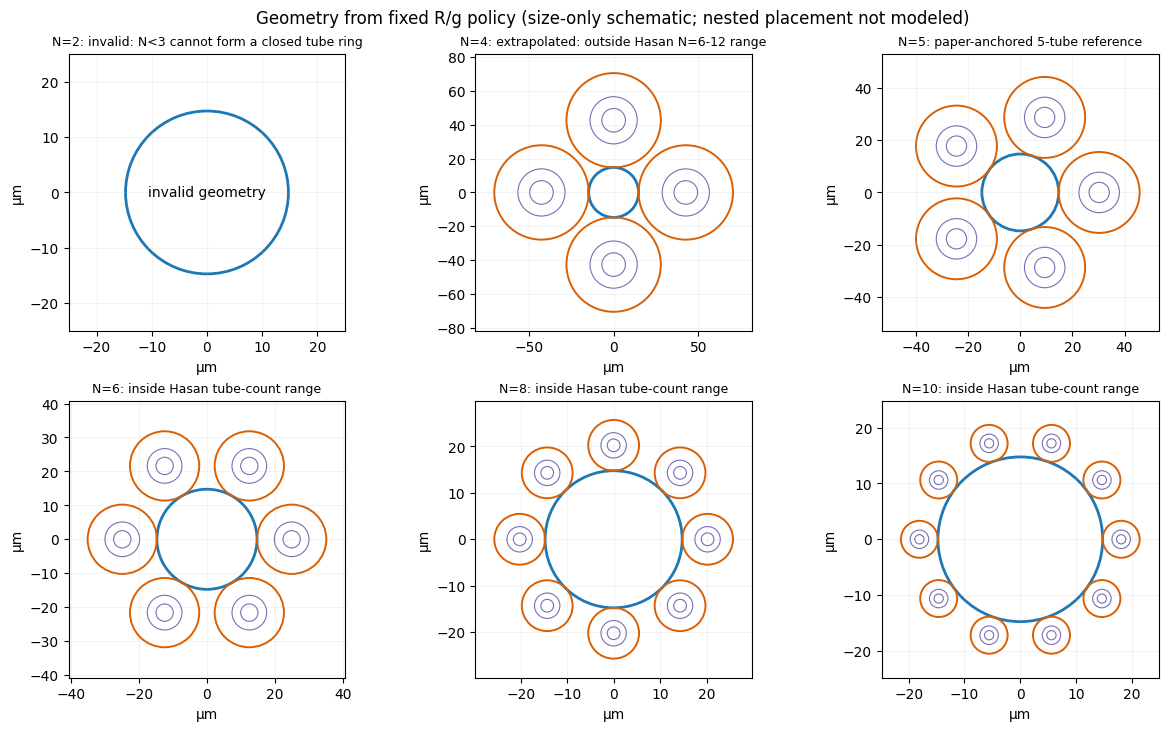

In [8]:
# Cross-section schematics at the reference core diameter.
fig, axes = plt.subplots(2, 3, figsize=(12.2, 7.2), constrained_layout=True)
for ax, n in zip(axes.flat, ALL_TUBE_COUNTS):
    geometry = make_geometry(n, REFERENCE_CORE_DIAMETER_UM)
    valid, status = geometry_validity(geometry)
    ax.add_patch(Circle((0, 0), geometry.core_radius_um, fill=False,
                        lw=2.0, color="#1f77b4"))
    if valid:
        center_radius = 0.5*(geometry.core_diameter_um + geometry.outer_tube_diameter_um)
        for k in range(n):
            phi = 2*np.pi*k/n
            x, y = center_radius*np.cos(phi), center_radius*np.sin(phi)
            ax.add_patch(Circle((x, y), 0.5*geometry.outer_tube_diameter_um,
                                fill=False, lw=1.4, color="#d95f02"))
            for level in range(1, geometry.nesting_order + 1):
                nested_d = geometry.outer_tube_diameter_um/(2**level)
                ax.add_patch(Circle((x, y), 0.5*nested_d,
                                    fill=False, lw=0.8, color="#7570b3"))
        radius_plot = 0.58*geometry.microstructure_diameter_um
    else:
        ax.text(0, 0, "invalid geometry", ha="center", va="center")
        radius_plot = 1.7*geometry.core_radius_um
    ax.set_xlim(-radius_plot, radius_plot)
    ax.set_ylim(-radius_plot, radius_plot)
    ax.set_aspect("equal")
    ax.set_title(f"N={n}: {status}", fontsize=9)
    ax.set_xlabel("µm")
    ax.set_ylabel("µm")
    ax.grid(True, alpha=0.15)
fig.suptitle(
    "Geometry from fixed R/g policy (size-only schematic; nested placement not modeled)",
    fontsize=12,
)
fig.savefig("dnanf_geometry_schematics.png", dpi=200, bbox_inches="tight")
plt.show()


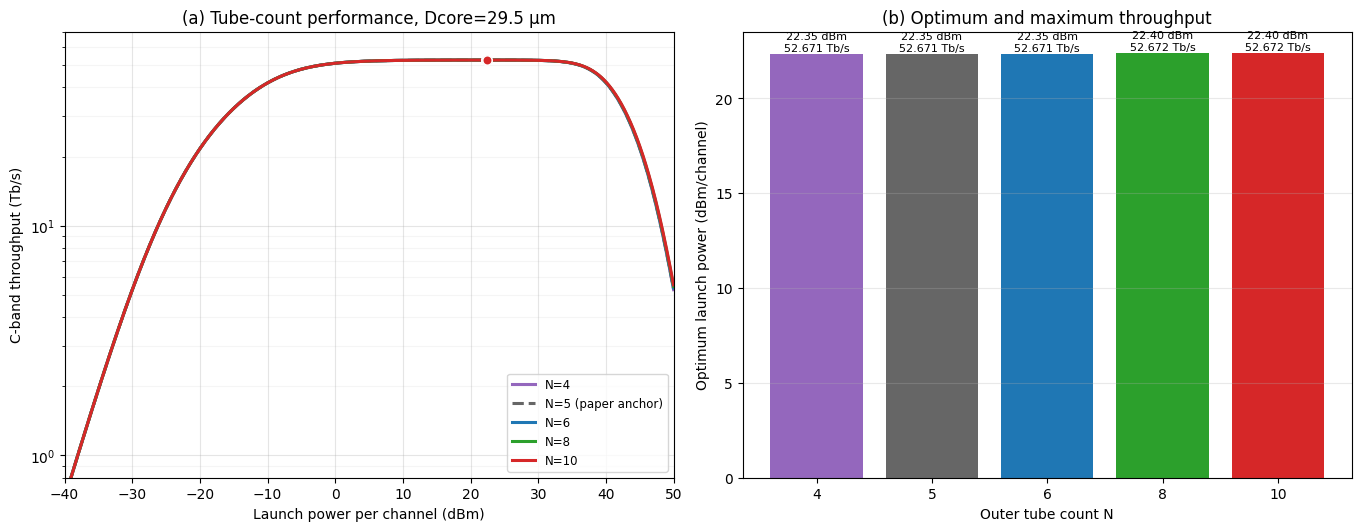

In [9]:
colors = {4:"#9467bd", 5:"#666666", 6:"#1f77b4", 8:"#2ca02c", 10:"#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

ax = axes[0]
for n in (4, 5, 6, 8, 10):
    result = results[(n, REFERENCE_CORE_DIAMETER_UM)]
    if not result["valid"]:
        continue
    label = f"N={n}" + (" (paper anchor)" if n == 5 else "")
    ax.plot(result["launch_dbm"], result["throughput_tbps"],
            lw=2.2, ls="--" if n == 5 else "-", color=colors[n], label=label)
    i = result["optimum_index"]
    ax.scatter(result["launch_dbm"][i], result["throughput_tbps"][i],
               color=colors[n], edgecolors="white", s=45, zorder=5)
ax.set_yscale("log")
ax.set_xlim(-40, 50)
ax.set_ylim(0.8, 70)
ax.set_xlabel("Launch power per channel (dBm)")
ax.set_ylabel("C-band throughput (Tb/s)")
ax.set_title("(a) Tube-count performance, Dcore=29.5 µm")
ax.grid(True, which="major", alpha=0.32)
ax.grid(True, which="minor", axis="y", alpha=0.12)
ax.legend(fontsize=8.5)

ax = axes[1]
valid_rows = baseline_tube_table[baseline_tube_table["valid"]].copy()
bars = ax.bar(valid_rows["tube_count"].astype(str), valid_rows["Popt_dbm_ch"],
              color=[colors[int(n)] for n in valid_rows["tube_count"]])
for bar, p, t in zip(bars, valid_rows["Popt_dbm_ch"], valid_rows["Tmax_Tbps"]):
    ax.text(bar.get_x()+bar.get_width()/2, p+0.03, f"{p:.2f} dBm\n{t:.3f} Tb/s",
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Outer tube count N")
ax.set_ylabel("Optimum launch power (dBm/channel)")
ax.set_title("(b) Optimum and maximum throughput")
ax.grid(True, axis="y", alpha=0.28)

fig.savefig("dnanf_geometry_aware_tube_performance.png", dpi=220, bbox_inches="tight")
plt.show()


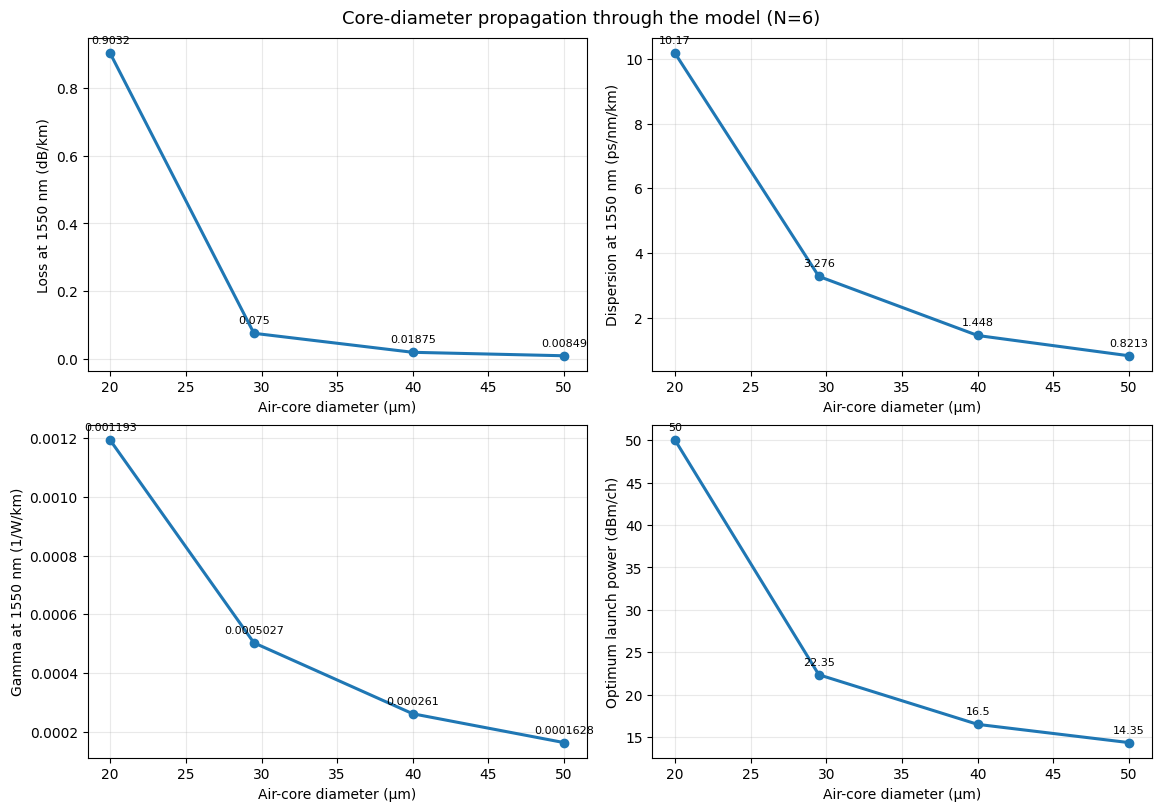

In [10]:
# Core-diameter sweep shown for N=6 (inside Hasan's tube-count range).
n_core_demo = 6
core_rows = summary[(summary["tube_count"] == n_core_demo) & summary["valid"]].copy()
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), constrained_layout=True)
metrics = [
    ("loss_1550_db_km", "Loss at 1550 nm (dB/km)"),
    ("D_1550_ps_nm_km", "Dispersion at 1550 nm (ps/nm/km)"),
    ("gamma_1550_1_W_km", "Gamma at 1550 nm (1/W/km)"),
    ("Popt_dbm_ch", "Optimum launch power (dBm/ch)"),
]
for ax, (column, ylabel) in zip(axes.flat, metrics):
    ax.plot(core_rows["core_diameter_um"], core_rows[column], marker="o", lw=2.2)
    for x, y in zip(core_rows["core_diameter_um"], core_rows[column]):
        ax.annotate(f"{y:.4g}", (x, y), xytext=(0, 7),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.set_xlabel("Air-core diameter (µm)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.28)
fig.suptitle("Core-diameter propagation through the model (N=6)", fontsize=13)
fig.savefig("dnanf_core_diameter_parameter_effects.png", dpi=220, bbox_inches="tight")
plt.show()


## 6. 결과 해석

1. **tube 수만 바꾸고 core, gap, tube diameter를 그대로 두면 구조가 겹치거나 큰 빈틈이 생길 수 있습니다.**
   이 노트북은 $R/g$를 보존하고 $d_{tube}$를 다시 계산하여 이 문제를 방지합니다.
2. tube 수 변화는 Hasan 모델에서 주로 $f_2$와 장파장 분산을 바꾸고, 그 결과
   $\beta_2\rightarrow\eta\rightarrow P_{opt}$가 변합니다.
3. core 직경 변화는 $n_{eff}$, 분산, $A_{eff}$, $\gamma$, leakage proxy를 동시에 바꾸므로
   tube-count-only 변화보다 시스템 성능에 더 큰 영향을 줄 수 있습니다.
4. 그러나 실제 tube 수 우열은 confinement loss와 HOM/IMI가 지배할 수 있습니다.
   기본 해석모델에는 그 tube별 full-vector 정보가 없으므로, 최종 설계 비교에는
   `FEM_OVERRIDES`를 채운 뒤 다시 실행해야 합니다.


## 7. 권장 레퍼런스

1. **Hasan, Akhmediev & Chang**, “Empirical formulae for hollow-core antiresonant fibers:
   dispersion and effective mode area,” *JLT* 36, 4060–4065 (2018),
   DOI: [10.1109/JLT.2018.2854722](https://doi.org/10.1109/JLT.2018.2854722).  
   `N=6,8,10`, $R/g$, $f_1/f_2$, dispersion 및 effective-area 비교의 직접 근거입니다.

2. **Habib, Markos & Amezcua-Correa**, “Impact of cladding elements on the loss performance
   of hollow-core anti-resonant fibers,” *Optics Express* 29, 3359–3374 (2021),
   DOI: [10.1364/OE.414814](https://doi.org/10.1364/OE.414814).  
   5-tube와 6-tube nested HC-ARF의 loss window 및 single-mode 성능 비교에 가장 직접적입니다.

3. **Poletti**, “Nested antiresonant nodeless hollow core fiber,” *Optics Express* 22,
   23807–23828 (2014), DOI: [10.1364/OE.22.023807](https://doi.org/10.1364/OE.22.023807).  
   nested 구조, leakage suppression, tube/core mode 결합의 기본 논문입니다.

4. **Michieletto et al.**, “Hollow-core fibers for high power pulse delivery,”
   *Optics Express* 24, 7103–7119 (2016),
   DOI: [10.1364/OE.24.007103](https://doi.org/10.1364/OE.24.007103).  
   tube 수, $d/D$, HOM suppression 및 bend-loss trade-off를 설명합니다.

5. **Vincetti**, “Empirical formulas for calculating loss in hollow core tube lattice fibers,”
   *Optics Express* 24, 10313–10325 (2016),
   DOI: [10.1364/OE.24.010313](https://doi.org/10.1364/OE.24.010313).  
   confinement, absorption, surface-scattering loss의 scaling law 참고문헌입니다.

6. **Numkam Fokoua et al.**, “Loss in hollow-core optical fibers: mechanisms, scaling rules,
   and limits,” *Advances in Optics and Photonics* 15, 1–85 (2023),
   [Optica article](https://opg.optica.org/aop/abstract.cfm?URI=aop-15-1-1).  
   실제 loss를 confinement, surface scattering, microbend, material absorption 등으로
   분리해 해석할 때 가장 유용한 리뷰입니다.
